In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/features.csv')
print("Shape:", df.shape)
df.head()

Shape: (233055, 55)


,floor_area_sqm,lease_commence_date,year,transaction_month,storey_midpoint,remaining_lease_years,flat_type_encoded,town_ANG MO KIO,town_BEDOK,town_BISHAN,...,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Apartment Loft,flat_model_Premium Maisonette,flat_model_Simplified,flat_model_Standard,flat_model_Terrace,flat_model_Type S1,flat_model_Type S2,resale_price
0,44.0,1979,2017,1,11.0,61.333333,2,True,False,False,...,False,False,False,False,False,False,False,False,False,232000.0
1,67.0,1978,2017,1,2.0,60.583333,3,True,False,False,...,True,False,False,False,False,False,False,False,False,250000.0
2,67.0,1980,2017,1,2.0,62.416667,3,True,False,False,...,True,False,False,False,False,False,False,False,False,262000.0
3,68.0,1980,2017,1,5.0,62.083333,3,True,False,False,...,True,False,False,False,False,False,False,False,False,265000.0
4,67.0,1980,2017,1,2.0,62.416667,3,True,False,False,...,True,False,False,False,False,False,False,False,False,265000.0


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['resale_price'])
y = df['resale_price']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=44
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=44
)

print(f"Train size:      {X_train.shape[0]:,} rows")
print(f"Validation size: {X_val.shape[0]:,} rows")
print(f"Test size:       {X_test.shape[0]:,} rows")
print(f"Features:        {X_train.shape[1]} columns")

Train size:      139,833 rows
Validation size: 46,611 rows
Test size:       46,611 rows
Features:        54 columns


In [30]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    random_state=44,
    eval_metric='rmse',
    early_stopping_rounds=50,
    tree_method='hist',

)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:177425.95176
[100]	validation_0-rmse:45769.01619
[200]	validation_0-rmse:39456.71931
[300]	validation_0-rmse:37168.45717
[400]	validation_0-rmse:35868.00117
[499]	validation_0-rmse:35002.34263


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X, y, dataset_name):
    predictions = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    mae = mean_absolute_error(y, predictions)
    r2 = r2_score(y, predictions)
    print(f"{dataset_name}:")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  MAE:  ${mae:,.0f}")
    print(f"  R²:   {r2:.4f}")
    print()

evaluate_model(model, X_train, y_train, "Train")
evaluate_model(model, X_val, y_val, "Validation")
evaluate_model(model, X_test, y_test, "Test")

Train:
  RMSE: $32,782
  MAE:  $23,811
  R²:   0.9703

Validation:
  RMSE: $35,002
  MAE:  $25,171
  R²:   0.9663

Test:
  RMSE: $34,758
  MAE:  $25,081
  R²:   0.9662



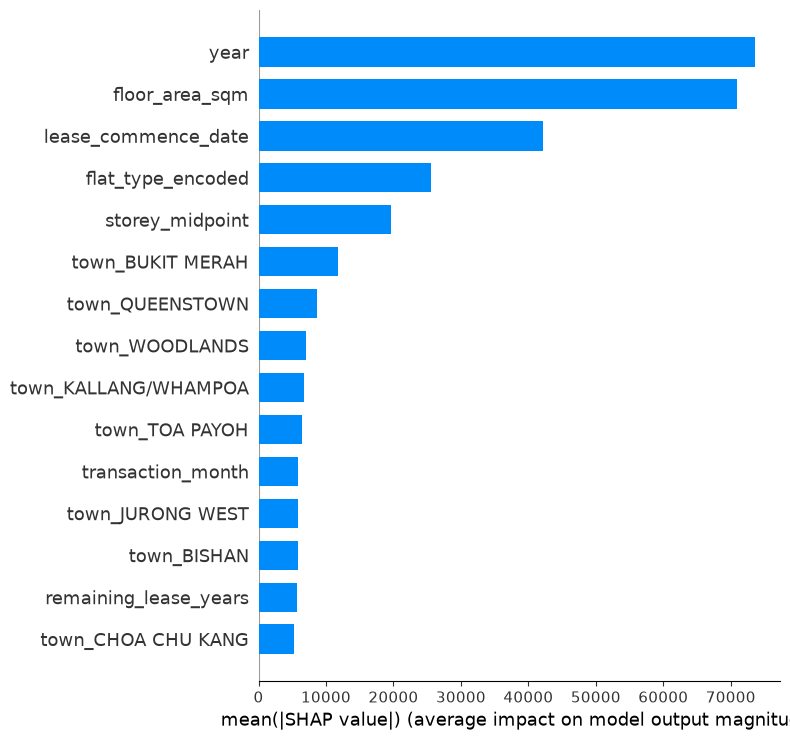

In [21]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar", max_display=15)

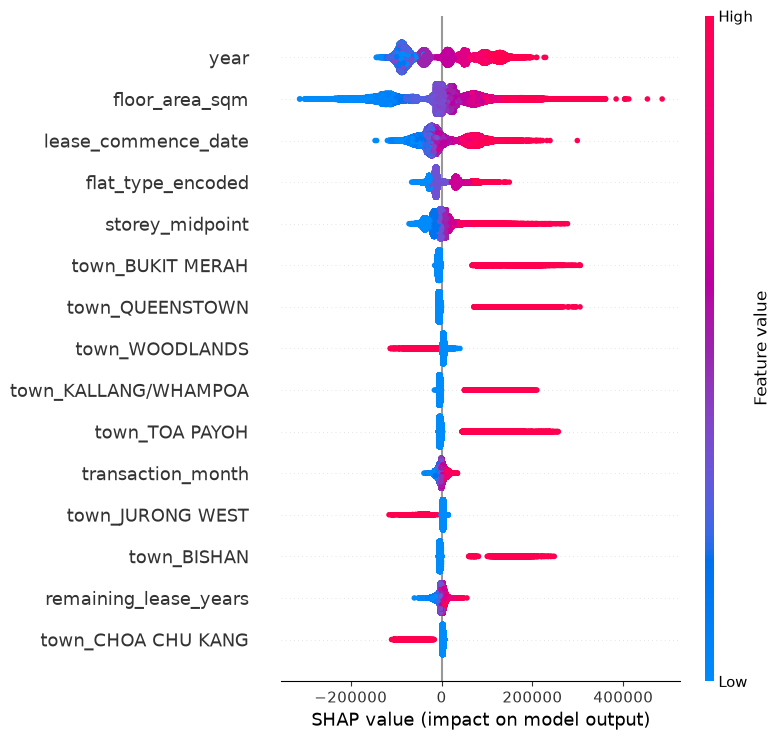

In [22]:
shap.summary_plot(shap_values, X_train, plot_type="dot", max_display=15)


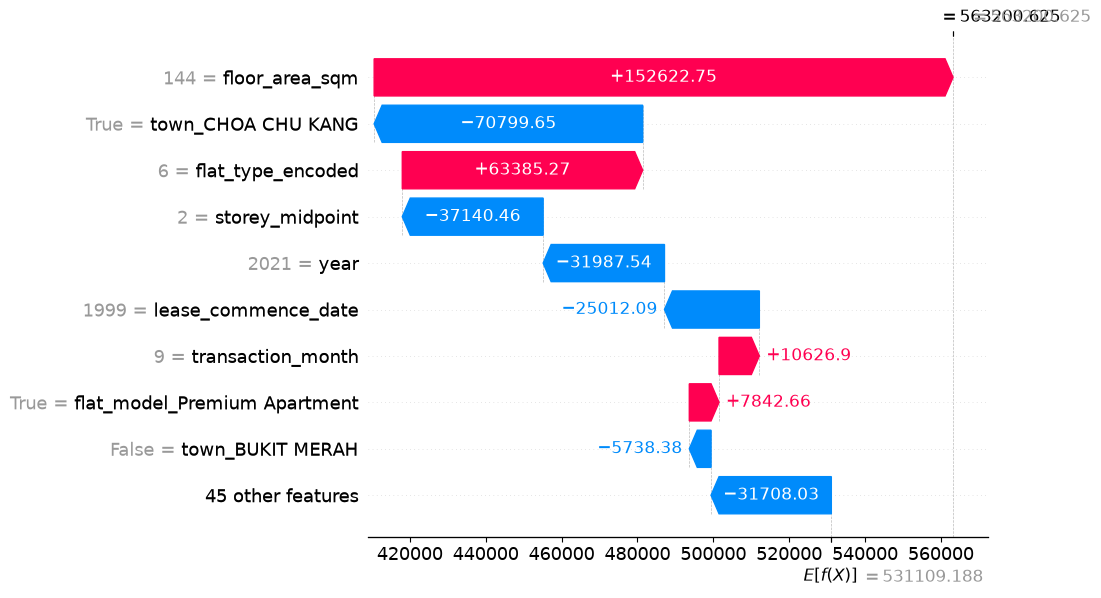

In [26]:
shap_values_exp = explainer(X_train.iloc[[0]])

shap.plots.waterfall(shap_values_exp[0])

In [27]:
import xgboost as xgb

quantiles = [0.1, 0.5, 0.9]
quantile_models = {}

for q in quantiles:
    print(f"Training quantile {q} model...")
    model_q = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=6,
        objective='reg:quantileerror',
        quantile_alpha=q,
        tree_method='hist',
        random_state=44
    )
    model_q.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    quantile_models[q] = model_q
    print(f"  Done.")

print("\nAll quantile models trained.")

Training quantile 0.1 model...
  Done.
Training quantile 0.5 model...
  Done.
Training quantile 0.9 model...
  Done.

All quantile models trained.


In [28]:
sample = X_test.iloc[:5]

lower = quantile_models[0.1].predict(sample)
median = quantile_models[0.5].predict(sample)
upper = quantile_models[0.9].predict(sample)

for i in range(5):
    print(f"Transaction {i+1}:")
    print(f"  Actual:     ${y_test.iloc[i]:,.0f}")
    print(f"  Prediction: ${lower[i]:,.0f} — ${median[i]:,.0f} — ${upper[i]:,.0f}")
    print()

Transaction 1:
  Actual:     $370,000
  Prediction: $366,861 — $391,573 — $424,481

Transaction 2:
  Actual:     $670,000
  Prediction: $621,219 — $662,324 — $696,913

Transaction 3:
  Actual:     $885,000
  Prediction: $871,636 — $933,279 — $1,020,872

Transaction 4:
  Actual:     $685,000
  Prediction: $520,496 — $579,011 — $638,433

Transaction 5:
  Actual:     $680,000
  Prediction: $666,441 — $705,710 — $771,076



In [31]:
import os

os.makedirs('models', exist_ok=True)

# Save baseline model
model.save_model('models/xgb_baseline.json')

# Save quantile models
quantile_models[0.1].save_model('models/xgb_q10.json')
quantile_models[0.5].save_model('models/xgb_q50.json')
quantile_models[0.9].save_model('models/xgb_q90.json')

print("All models saved to models/")

All models saved to models/
